In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from scipy.special import expit

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 14})

SEED = 314159
TRAIN_TEST_SPLIT = 0.80


# Калибровка вероятностей

Часто при обучении моделей для бинарной классификации хочется получать не только предсказанную метку класса, но и вероятность положительного класса. Предсказанная вероятность может служить как мера уверенности нашего алгоритма. Также это позволяет сравнивать две модели, у которых одинаковые метрики точности. Этот тип метрик конкретно используется в высокорисковых приложениях, позволяя нам не рассматривать результаты модели как реальные вероятности, а вместо этого выходить за рамки необработанных результатов и предотвращать плохое принятие решений или ложную интерпретацию.

В задаче бинарной классификации откалиброванным алгоритмом называют такой алгоритм, для которого доля положительных примеров (на основе реальных меток классов) для предсказаний в окрестности произвольной вероятности $\hat p$ совпадает с этим значением $p$. Например, если взять объекты, для которых предсказанные вероятности близки к 0.7, то окажется, что среди них 70\% принадлежат положительному классу.
На математическом языке это выглядит так: если $\hat p$  — предсказанная вероятность класса 1, то $P(y=1|q(x_i)=\hat p)=\hat p$.

Однако некоторые алгоритмы не выдают корректные вероятности классов. В таком случае вероятности модели нужно калибровать.

Для визуализации откалиброванности алгоритма можно построить калибровочную кривую. На этой кривой абсцисса точки соответствуют значению $p$ (предсказаний алгоритма), а ордината соответствует доле примеров, для которых алгоритм предсказал вероятность, близкую к $p$. В идеальном случае эта кривая совпадает с прямой $y = x$. 

Чаще всего  $\hat p$ - это какие-то вещественные числа, которые будут разными для разных $y_i$. Для того, чтобы оценить именно вероятности, отрезок $[0, 1]$ можно разбить на бины, и для каждого бина вычислить долю класса 1 и,соответственно, среднюю предсказанную вероятность.

Пример диаграммы калибровки: 

![calib_1](../additional_materials/images/calib_1.png)


У идеально откалиброванной модели зеленая и розовая линии должны совпадать. Однако в нашем случае модель завышает свою оценку. Как отделить положительные примеры от отрицательных (дать дискретный класс)? Обычно пользуются порогом (логично сделать 0.5). Но нам придется сдвинуть порог вправо - так, чтобы разбить зеленый график пополам по вертикали.

Часто картинка иная. В таком случае говорят о слишком увернной модели (overconfident) или неуверенной (underconfident). В первом случае молдель предсказывает вероятности ближе к экстремальным, ченм стоит (0.1 вместо 0.2 и 0.9 вместо 0.1), во втором же наоборот, сводит все вероятности к центру интервала.

![calib_2](../additional_materials/images/calib_2.png)

Часто слишком большой уверенностью грешат нейросети, так как их учат именно на метках классов. Способ с этим бороться - Label smoothing, когда вместо метки класса модели дают слегка сглаженное значение (0.9 вместо 1, и т.д.). Альтернативный путь - hard samples mining, когда мы заставляем модель больше обращать внимания на объекты ближе к границе разделения.

Второй же случай возникает, если мы, наоборот, слишком сильно уделяем внимание границе. Это часто происходит в SVM или бэггинге.

Ниже на синтетическом примере посмотрим на типичные калибровочные кривые для overconfident и underconfident моделей: генерируем данные с нелинейной границей, получаем «предсказания» и искусственно искажаем их к экстремумам или к центру интервала. Кроме того, рассмотрим случай, когда модель предсказывает отношение классов, не зависящее от х.

In [40]:
from sklearn.datasets import make_moons

X_syn, y_syn = make_moons(n_samples=2000, noise=0.25, random_state=SEED)
X_tr, X_te, y_tr, y_te = train_test_split(X_syn, y_syn, test_size=0.4, random_state=SEED)
clf_syn = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
p_real = np.clip(clf_syn.predict_proba(X_te)[:, 1], 1e-6, 1 - 1e-6)

def logit(p: np.ndarray) -> np.ndarray:
    return np.log(p / (1 - p))
    
# to get new probabilities we need to make more strict logits and then return back to probas
p_over = 1. / (1 + np.exp(-5 * logit(p_real))) 
p_under = 0.5 + 0.35 * (p_real - 0.5)
p_constant = np.full_like(p_real, y_te.mean())

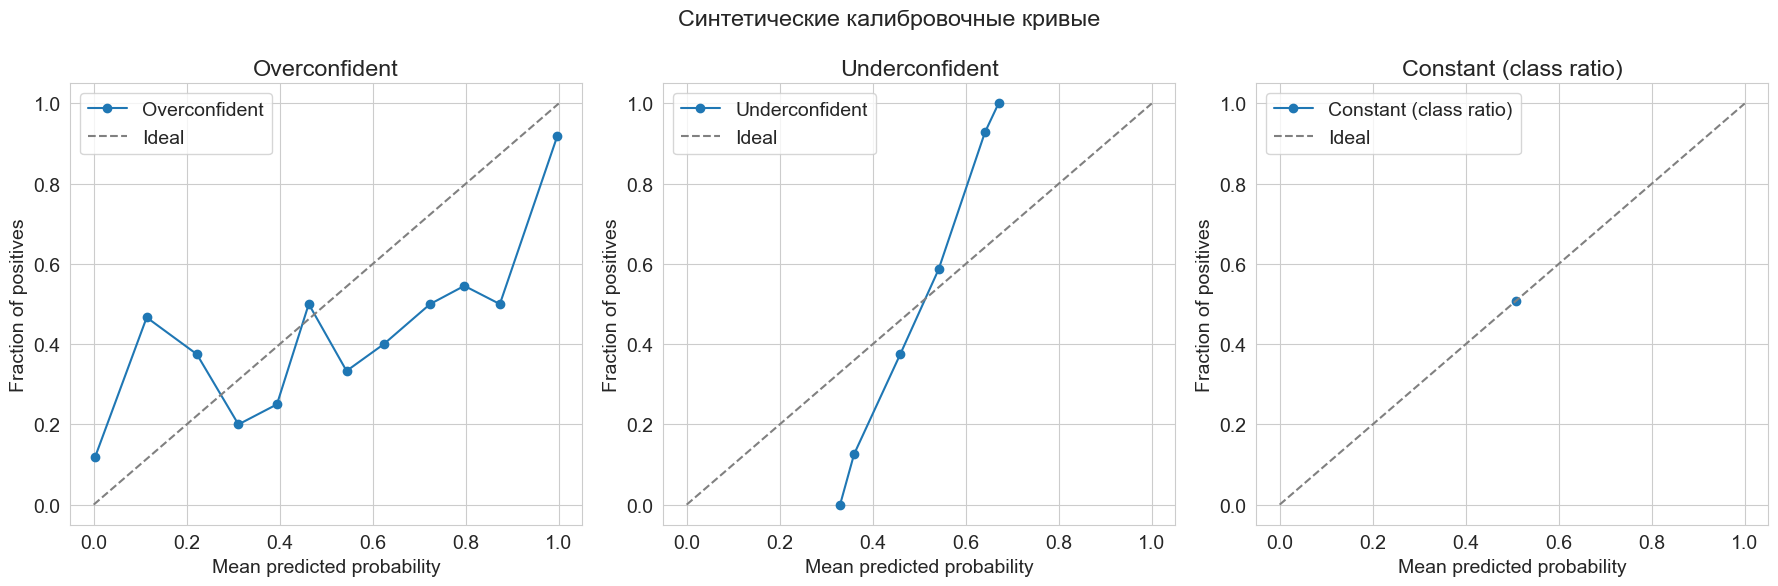

In [41]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
for ax, probs, label in zip(axs, [p_over, p_under, p_constant], ['Overconfident', 'Underconfident', 'Constant (class ratio)']):
    t, p = calibration_curve(y_te, probs, n_bins=12)
    ax.plot(p, t, marker='o', label=label)
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(label)
    ax.legend()
plt.suptitle('Синтетические калибровочные кривые')
plt.tight_layout()
plt.show()

In [42]:
data = pd.read_csv('../datasets/riceClassification.csv')


Отмасштабируем данные и подготовим трейн и тест.

In [43]:
X = data.drop(columns=['id', 'Class'])
y = data.Class

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=999)
scaler = StandardScaler().fit(X_train, y_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

**Задание**: Оцените сбалансированность классов

Распределение классов:
Class
1    9985
0    8200
Name: count, dtype: int64

Доли классов:
Class
1    0.549079
0    0.450921
Name: proportion, dtype: float64

Соотношение классов: 0.82:1
Доля миноритарного класса: 45.09%


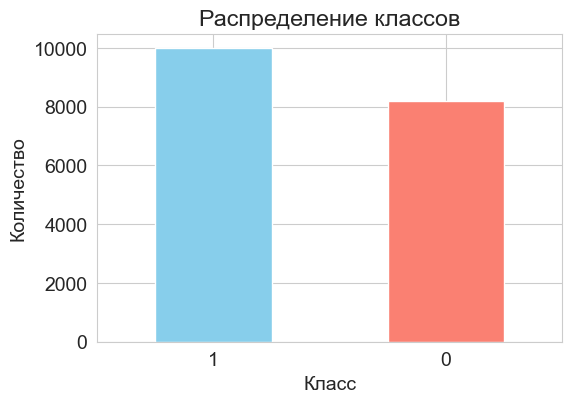

In [ ]:
class_counts = y.value_counts()
class_ratios = y.value_counts(normalize=True)
print("Распределение классов:")
print(class_counts)
print("\nДоли классов:")
print(class_ratios)
print(f"\nСоотношение классов: {class_counts[0] / class_counts[1]:.2f}:1")
print(f"Доля миноритарного класса: {class_ratios.min():.2%}")

plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Распределение классов')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()


Обучим метод опорных векторов (SVC — Support Vector Classification) и логистическую регрессию, в качестве метрики возьмем ROC-AUC. Для сравнения также посмотрим на градиентный бустинг.
В качестве скоров будем рассматривать выход decision_function. Этот метод возвращает confidence score для семплов и пропорционален расстоянию до разделяющей гиперплоскости, взятого со знаком. Он вернет матрицу размера (n_samples, n_classes). В бинарном случае, будет возвращен скор для класса 1.

Вопрос: Какая формула для decision function у логистической регрессии?

ОТВЕТ НА ВОПРОС
для логистической регрессии decision function — это линейная комбинация признаков:
$$f(x) = w^T x + b = \sum_{j=1}^{d} w_j x_j + b$$

Вероятность класса 1 получается применением сигмоиды:
$$P(y=1|x) = \sigma(f(x)) = \frac{1}{1 + \exp(-(w^T x + b))}$$

Таким образом, `decision_function` возвращает $w^T x + b$, а `predict_proba` применяет к нему сигмоиду

In [45]:
svc = LinearSVC(max_iter=100000, C=0.1).fit(X_train, y_train)
svc_pred = svc.decision_function(X_test)
print('SVC ROC-AUC:', roc_auc_score(y_test, svc_pred))

SVC ROC-AUC: 0.9991453206707389


In [46]:
svc_pred

array([ 3.25919713,  1.95223252,  1.93751674, ...,  0.46630054,
        2.95728847, -1.77506552], shape=(7274,))

In [47]:
svc.predict(X_test)

array([1, 1, 1, ..., 1, 1, 0], shape=(7274,))

In [48]:
print('SVC ROC-AUC (on predictions):', roc_auc_score(y_test, svc.predict(X_test)))

SVC ROC-AUC (on predictions): 0.9894067537906887


In [49]:
# предскажите вероятности с помощью SVM

In [50]:
lr = LogisticRegression(max_iter=100000, C=0.1).fit(X_train, y_train)
lr_pred = lr.decision_function(X_test)
print('Logistic regression ROC-AUC:', roc_auc_score(y_test, lr_pred))

Logistic regression ROC-AUC: 0.9990017675125695


In [51]:
gb = GradientBoostingClassifier(n_estimators=300, max_depth=3, random_state=SEED).fit(X_train, y_train)
gb_pred = gb.decision_function(X_test) # gb.predict_proba(X_test)[:, 1]
print('Gradient Boosting ROC-AUC:', roc_auc_score(y_test, gb_pred))

Gradient Boosting ROC-AUC: 0.9983573809676445


У случайного леса нет метода decision_function, поэтому просто посмотрим на точность.

In [52]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED).fit(X_train, y_train)
rf_pred = rf.predict_proba(X_test)[:, 1]
print('Random Forest ROC-AUC:', roc_auc_score(y_test, rf_pred))

Random Forest ROC-AUC: 0.9991008275866279


In [53]:
lr.predict(X_test)

array([1, 1, 1, ..., 1, 1, 0], shape=(7274,))

In [54]:
lr.predict_proba(X_test)

array([[7.52180938e-05, 9.99924782e-01],
       [2.37484102e-03, 9.97625159e-01],
       [4.28557243e-03, 9.95714428e-01],
       ...,
       [1.72933989e-01, 8.27066011e-01],
       [2.10618110e-04, 9.99789382e-01],
       [9.98955458e-01, 1.04454161e-03]], shape=(7274, 2))

In [55]:
lr.classes_

array([0, 1])

Судя по метрикам, мы практически идеально предсказываем класс всеми моделями.

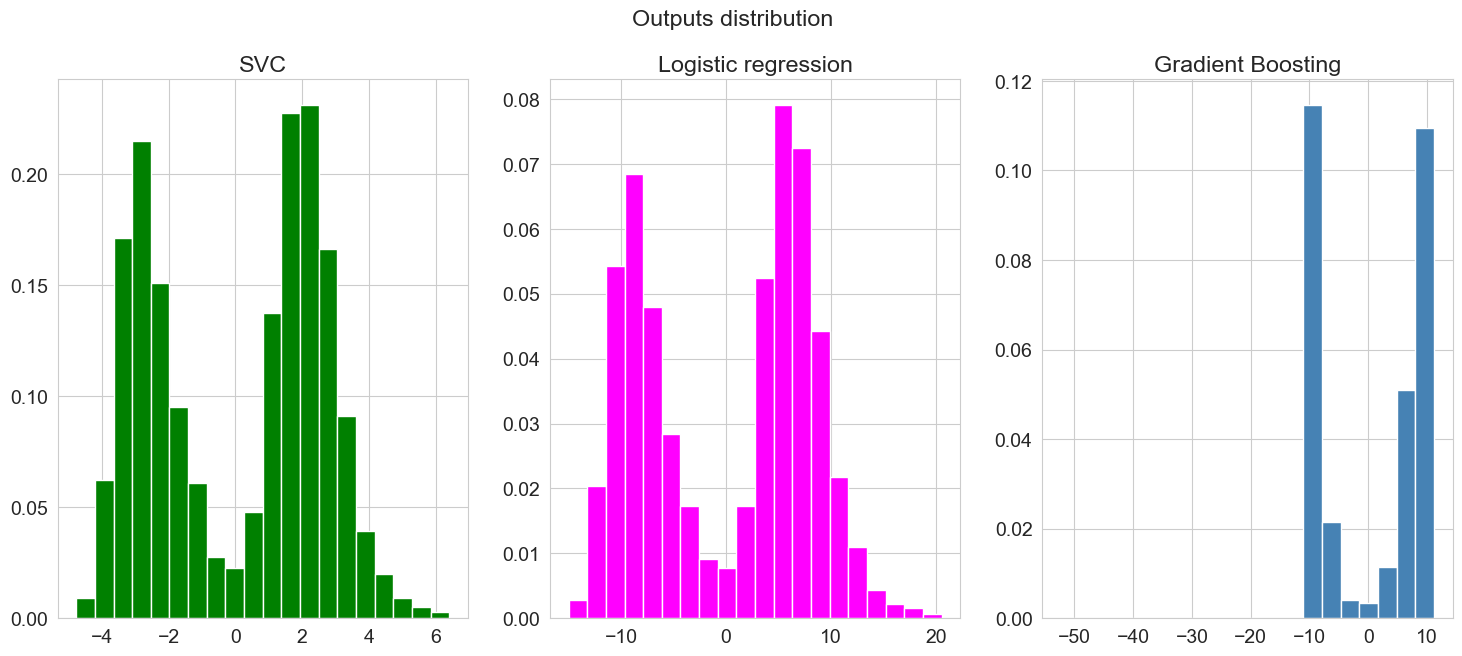

In [56]:
fig, axs = plt.subplots(1, 3, figsize=(18, 7))

axs[0].hist(svc_pred, bins=20, color='green', density='True')
axs[1].hist(lr_pred, bins=20, color='magenta', density='True')
axs[2].hist(gb_pred, bins=20, color='steelblue', density='True')

axs[0].set_title('SVC')
axs[1].set_title('Logistic regression')
axs[2].set_title('Gradient Boosting')

plt.suptitle('Outputs distribution')
plt.show()

Мы видим, что скоры могут принимать любые вещественные значения. Но для оценивания вероятностей нам нужно перевести их в промежуток 
$[0,1]$. С логистической регрессией несложно: можно добавить сигмоиду или софтмакс, ведь модель и обучалась так, чтобы $\sigma (W^Tx)$
 приближало вероятности. Для SVC у нас нет такой опции, поэтому воспользуемся масштабированием через минимум-максимум.

Вопрос: а как вычисляются вероятности для бустинга?

ОТВЕТ НА ВОПРОС
В градиентном бустинге вероятности вычисляются через сумму предсказаний всех деревьев:

1. Каждое дерево $h_m(x)$ предсказывает значение в пространстве градиентов
2. Итоговый скор: $F(x) = \sum_{m=1}^{M} \nu \cdot h_m(x)$, где $\nu$ — learning rate
3. Вероятность получается применением сигмоиды: $P(y=1|x) = \sigma(F(x)) = \frac{1}{1 + \exp(-F(x))}$.

В `predict_proba` возвращается именно $\sigma(F(x))$, а в `decision_function` — $F(x)$.


In [57]:
svc_pred = (svc_pred - svc_pred.min()) / (svc_pred.max() - svc_pred.min())
lr_pred = lr.predict_proba(X_test)[:, 1]
gb_pred = gb.predict_proba(X_test)[:, 1]
rf_pred = rf.predict_proba(X_test)[:, 1]

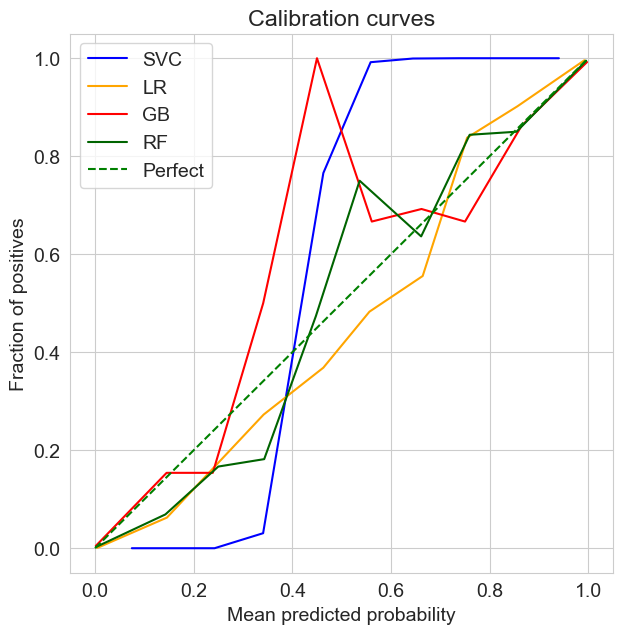

In [58]:
plt.figure(figsize=(7, 7))

svc_true_prob, svc_pred_prob = calibration_curve(y_test, svc_pred, n_bins=10)
lr_true_prob, lr_pred_prob = calibration_curve(y_test, lr_pred, n_bins=10)
gb_true_prob, gb_pred_prob = calibration_curve(y_test, gb_pred, n_bins=10)
rf_true_prob, rf_pred_prob = calibration_curve(y_test, rf_pred, n_bins=10)

plt.plot(svc_pred_prob, svc_true_prob, label='SVC', color='blue')
plt.plot(lr_pred_prob, lr_true_prob, label='LR', color='orange')
plt.plot(gb_pred_prob, gb_true_prob, label='GB', color='red')
plt.plot(rf_pred_prob, rf_true_prob, label='RF', color='darkgreen')
plt.plot([0, 1], [0, 1], label='Perfect', linestyle='--', color='green')

plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration curves')
plt.legend()
plt.show()


Мы видим, что кривая для логистической регрессии неплохо приближает диагональ, при этом в бустинге можно вообразить чрезмерную уверенность. С SVC все гораздо хуже. Но попробуем откалибровать модели разными способами.

Что интересно с ансамблями: у них есть явный горб посередине интервала. Это значит, что моделям в принципе сложновато предсказывать крайние значения вероятностей. Хорошее объяснение этому дано в [статье](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://www.cs.cornell.edu/~alexn/papers/calibration.icml05.crc.rev3.pdf), цитата из нее: 
> Methods such as bagging and random forests that average predictions from a base set of models can have difficulty making predictions near 0 and 1 because variance in the underlying base models will bias predictions that should be near zero or one away from these values. Because predictions are restricted to the interval [0,1], errors caused by variance tend to be one-sided near zero and one. 

> For example, if a model should predict $p=0$ for a case, the only way bagging can achieve this is if all bagged trees predict zero. If we add noise to the trees that bagging is averaging over, this noise will cause some trees to predict values larger than 0 for this case, thus moving the average prediction of the bagged ensemble away from 0. We observe this effect most strongly with random forests because the base-level trees trained with random forests have relatively high variance due to feature subsetting.”

Другой способ визуализировать то же самое - диаграмма надёжности (reliability diagram):

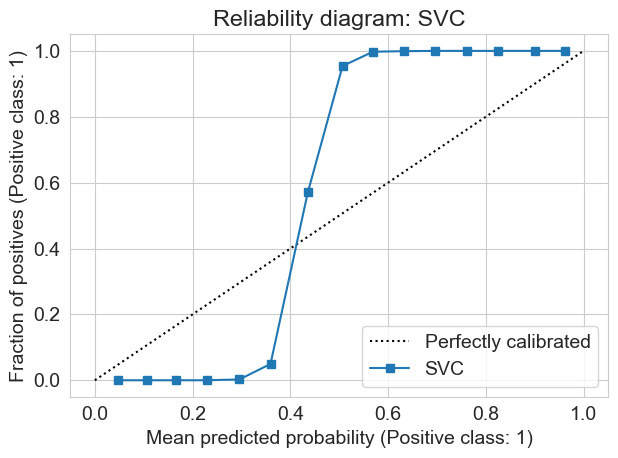

In [59]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_predictions(y_test, svc_pred, n_bins=15, name='SVC')
plt.title('Reliability diagram: SVC')
plt.tight_layout()
plt.show()

**Задание**: Постройте гистограмму предсказанных вероятностей для двух классификаторов.

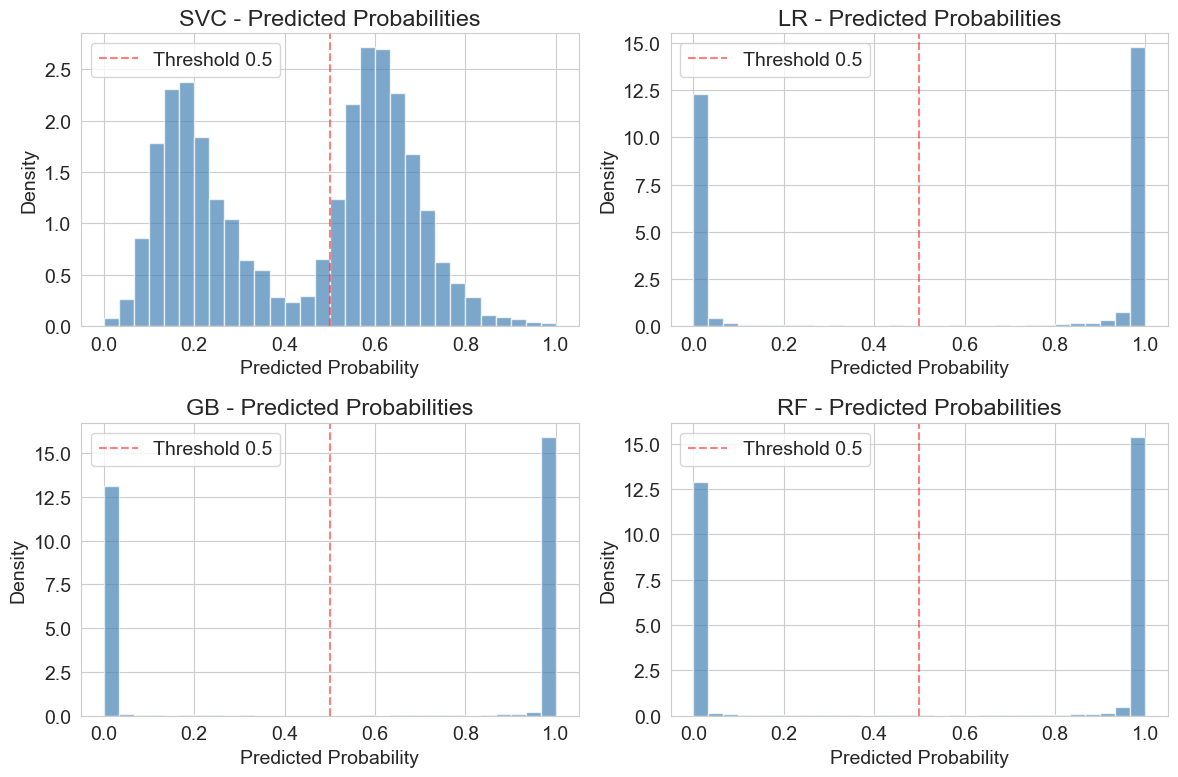

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (name, pred) in zip(axes.flatten(), [
    ('SVC', svc_pred), ('LR', lr_pred), ('GB', gb_pred), ('RF', rf_pred)
]):
    ax.hist(pred, bins=30, color='steelblue', alpha=0.7, density=True)
    ax.set_title(f'{name} - Predicted Probabilities')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Density')
    ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Threshold 0.5')
    ax.legend()

plt.tight_layout()
plt.show()


# Калибровка Платта
Пусть наш алгоритм выдаёт значения $f(x)$ (могут не быть вероятностями). Тогда итоговая вероятность строится как:

$$P(y = 1 | x) = \frac{1}{1+\exp (af(x) + b)},$$

где $a, b$ -- скалярные параметры. Эти параметры настраиваются методом максимума правдоподобия (минимизируя логистическую функцию потерь):
$$- \sum_{i=1}^N[y_i \log{(\sigma(af(x_i)+b))} + (1 - y_i) \log{(1-\sigma(af(x_i)+b))}] \to min_{a,b}$$

Алгоритм: на выходах $f(x)$ базовой модели обучается логистическая регрессия без регуляризации; откалиброванное предсказание — $\sigma(af(x)+b)$.

Вопрос: на какой выборке обучается модель?

Также Платт предложил для избежания переобучения изменить метки объектов в NLL ($y_i$ и $1-y_i$) на следующие значения:

$t_{+} = \frac{N_{+} + 1}{N_{-} + 2}$ для положительных примеров и

$t_{-} = \frac{1}{N_{-} + 2}$ для отрицательных, где $N_{-}$ и $N_{+}$ число негативных и позитивных семплов в выборке. 

Калибровку Платта можно представить как применение логистической регрессии поверх предсказаний другого алгоритма с отключенной регуляризацией. 

Калибровка Платта неплохо справляется с SVM, но для более хитрых классификаторов может спасовать. В целом, можно показать, что этот метод хорошо работает, если для каждого из истинных классов предсказанные вероятности распределены нормально с одинаковыми дисперсиями (подробнее [здесь](https://research-information.bris.ac.uk/ws/portalfiles/portal/154625753/Full_text_PDF_final_published_version_.pdf)). 

Вообще эта калибровка относится к большой группе параметрических методов калибрации, туда же относится бета-калибрация (в предположении бета-распределения) или калибрация Дирихле (для мультикласса). 

ОТВЕТ НА ВОПРОС
Калибровка Платта обучается на отдельной калибровочной выборке, которая не должна совпадать с обучающей выборкой базовой модели. В `CalibratedClassifierCV` это реализуется через кросс-валидацию (`cv=3`):

1. Обучающая выборка разбивается на $K$ фолдов.
2. Для каждого фолда $k$:
   - Базовая модель обучается на $K-1$ фолдах.
   - На оставшемся фолде получаются предсказания (decision function).
   - На этих предсказаниях и истинных метках обучается логистическая регрессия (калибратор).
3. Итоговая модель — это ансамбль из $K$ калиброванных моделей.

In [61]:
sigmoid_svc = CalibratedClassifierCV(svc, cv=3, method='sigmoid').fit(X_train, y_train)
sigmoid_svc_pred = sigmoid_svc.predict_proba(X_test)[:, 1]
print('SVC ROC-AUC:', roc_auc_score(y_test, sigmoid_svc_pred))

SVC ROC-AUC: 0.9991337204155334


In [62]:
sigmoid_lr = CalibratedClassifierCV(lr, cv=3, method='sigmoid').fit(X_train, y_train)# YOUR CODE: make the same for LR
sigmoid_lr_pred = sigmoid_lr.predict_proba(X_test)[:, 1]
print('Logistic regression ROC-AUC:', roc_auc_score(y_test, sigmoid_lr_pred))

Logistic regression ROC-AUC: 0.9989783380497528


In [63]:
sigmoid_rf = CalibratedClassifierCV(rf, cv=3, method='sigmoid').fit(X_train, y_train)# YOUR CODE: make the same for LR
sigmoid_rf_pred = sigmoid_rf.predict_proba(X_test)[:, 1]
print('LRandom forest ROC-AUC:', roc_auc_score(y_test, sigmoid_rf_pred))

LRandom forest ROC-AUC: 0.9990831219339457


In [64]:
sigmoid_gb = CalibratedClassifierCV(gb, cv=3, method='sigmoid').fit(X_train, y_train)
sigmoid_gb_pred = sigmoid_gb.predict_proba(X_test)[:, 1]
print('Gradient Boosting ROC-AUC:', roc_auc_score(y_test, sigmoid_gb_pred))

Gradient Boosting ROC-AUC: 0.9990615622491064


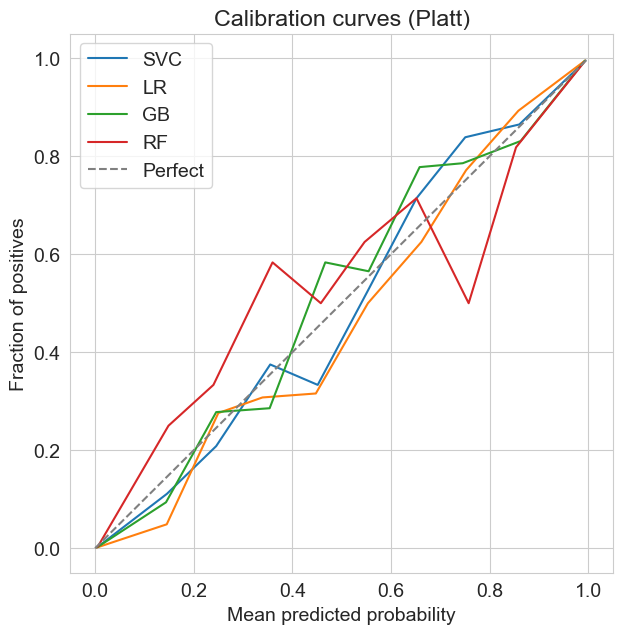

In [65]:
plt.figure(figsize=(7, 7))
for name, pred in [('SVC', sigmoid_svc_pred), ('LR', sigmoid_lr_pred), ('GB', sigmoid_gb_pred), ('RF', sigmoid_rf_pred)]:
    true_prob, pred_prob = calibration_curve(y_test, pred, n_bins=10)
    plt.plot(pred_prob, true_prob, label=name)
plt.plot([0, 1], [0, 1], label='Perfect', linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration curves (Platt)')
plt.legend()
plt.show()

Как мы видим, калибровка Платта действительно улучшила вероятности, который получаются у SVC, RF и GB. При этом кривая для логистической регрессии практически не сдвигается. 

# Изотоническая регрессия
В этом методе также строится отображение из предсказаний модели в откалиброванные вероятности. Используется изотоническая функция: неубывающая, кусочно-постоянная; $x$ — выходы алгоритма, $y$ — целевая переменная. 

Мы хотим найти такую функцию $m(t)$: $P(y = 1 | x) = m(f(x))$. Она настраивается под квадратичную ошибку:

$$m = \arg \min_{z} \sum (y_i - z(f(x_i))^2,$$

с помощью специального алгоритма (Pool-Adjacent-Violators Algorithm):

---
*Вход: обучающая выборка — пары (скор модели $f_i$, метка $y_i \in \{0,1\}$), отсортированные по возрастанию $f_i$.*

Для каждой точки $i$ задаём один сегмент: оценка вероятности сегмента $m_{i,i} = y_i$ (метка точки), вес сегмента $w_{i,i} = 1$.

В цикле, пока есть нарушение изотонности — два соседних сегмента $(k, i-1)$ и $(i, l)$, у которых $m_{k,i-1} \geq m_{i,l}$ — объединяем их в один $(k, l)$: новый вес $w_{k,l} = w_{k,i-1} + w_{i,l}$, новая оценка $m_{k,l} = (w_{k,i-1} m_{k,i-1} + w_{i,l} m_{i,l}) / w_{k,l}$; заменяем два старых сегмента одним и повторяем.

*Выход: кусочно-постоянная функция $m(f)$: для любого скора $f$ значение $m(f)$ — это $m_{i,j}$ того сегмента $(i,j)$, в диапазон которого попадает $f$.*

---

В результате калибровки получаем надстройку над нашей моделью, которая применяется поверх предсказаний базовой модели. В случае мультиклассовой классификации каждый класс калибруется отдельно против остальных (one-versus-all), вероятности при предсказании нормируются.

Этот метод более общий, чем калибровка Платта, так как единственное условие для калибровочной функции - чтобы она была изотонической. Этот метод склонен к переобучению, поэтому его рекомендуется применять только для больших выборок.


In [66]:
isotonic_svc = CalibratedClassifierCV(svc, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_svc_pred = isotonic_svc.predict_proba(X_test)[:, 1]
print('SVC ROC-AUC:', roc_auc_score(y_test, isotonic_svc_pred))

SVC ROC-AUC: 0.9990992249197903


In [67]:
# YOUR CODE: Make the same for LR
isotonic_lr = CalibratedClassifierCV(lr, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_lr_pred = isotonic_lr.predict_proba(X_test)[:, 1]
print('LR ROC-AUC:', roc_auc_score(y_test, isotonic_svc_pred))

LR ROC-AUC: 0.9990992249197903


In [68]:
isotonic_gb = CalibratedClassifierCV(gb, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_gb_pred = isotonic_gb.predict_proba(X_test)[:, 1]
print('Gradient Boosting ROC-AUC:', roc_auc_score(y_test, isotonic_gb_pred))

Gradient Boosting ROC-AUC: 0.9989955857976244


In [69]:
isotonic_rf = CalibratedClassifierCV(rf, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_rf_pred = isotonic_rf.predict_proba(X_test)[:, 1]
print('Random Forest ROC-AUC:', roc_auc_score(y_test, isotonic_rf_pred))

Random Forest ROC-AUC: 0.9991279584466648


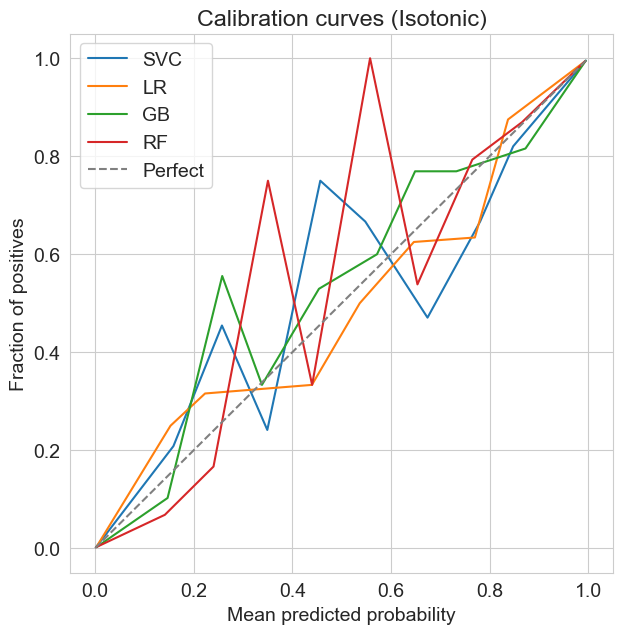

In [70]:
plt.figure(figsize=(7, 7))
for name, pred in [('SVC', isotonic_svc_pred), ('LR', isotonic_lr_pred), ('GB', isotonic_gb_pred), ('RF', isotonic_rf_pred)]:
    true_prob, pred_prob = calibration_curve(y_test, pred, n_bins=10)
    plt.plot(pred_prob, true_prob, label=name)
plt.plot([0, 1], [0, 1], label='Perfect', linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration curves (Isotonic)')
plt.legend()
plt.show()

Изотоническая регрессия немного подпортила кривую калибрации для моделей. Судя по всему, олна переобучилась.

## Мультикласс
У нас есть как минимум три варианта определить, что означает мультиклассовая калиброванность. Например, по мере увеличения строгости:
1) Учитывать только самую высокую вероятность. Для него мы требуем, чтобы среди всех случаев, где вероятность наиболее вероятного класса прогнозируется как $c$, ожидаемая точность была бы $c$. $P(Y=i|\hat p_i(x)=q_i)=q_i, i=\arg\max_j \hat p_j (X)$
2) Учитывать маргинальные вероятности. Тут мы хотим, чтобы все one-vs-rest вероятности были откалиброваны: $P(Y=i|\hat p_i(x)=q_i)=q_i, i=1...k$.
3) Учитывать весь вектор вероятностей. Т.е. чтобы пропорции классов для семплов с определенным вектором предсказаний былит такие же, как и весь вектор предсказаний:  $P(Y=i|\hat p(x)=q)=q_i, i=1...k$. 
   
Чаще всего используется определение слабой калиброванности (1). Однако, в случае чувствительной к стоимости постановки задачи оно может быть слишком слабым.


## Оценка качества калибровки

Мы что-то поняли по графикам, но как оценить численно улучшение предсказания вероятностей? Для этого есть свои метрики.

**Maximum calibration error**. Самый простой способ, впрочем — он наследник идеи с калибровочной кривой. А именно, разобьём отрезок 
$[0,1]$ на бины $B_1, B_2, ..., B_k$ по предсказанным вероятностям $\overline y(x_i)$ и вычислим следующее:
$$ \max_{j=1,..,k}|{\overline y(B_k) - \overline q (B_k) }|$$
Где $\overline y(B_k) $ - средняя предсказанная вероятность, $ \overline q (B_k) $ - среднее значение уверенности.

**Expected Calibration Error (ECE)** считает среднюю разницу: $$ \sum^k_{j=1}{{\|B_j\|}\over{N}}{| {\overline y(B_k) - \overline q (B_k) }|},$$
где $\|B_j\|$ - число семплов в бине. Бинны обычно строят равными по длине отрезка $[0,1]$ (uniform) или по квантилям предсказаний (quantile); веса $|B_j|/N$ делают вклад каждого бина пропорциональным его размеру.

Проблема этих способов в том, что мы можем очень по-разному предсказывать в каждом из бинов вероятности (в том числе константой) без ущерба для метрики.

Применим метрику калибрации:

In [82]:
def binary_ECE(y_true: np.ndarray, y_prob: np.ndarray, n_bins: int = 10) -> float:
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n = len(y_true)
    for i in range(n_bins):
        low, high = bin_edges[i], bin_edges[i + 1]
        mask = (y_prob >= low) & (y_prob <= high) if i == n_bins - 1 else (y_prob >= low) & (y_prob < high)
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += mask.sum() * np.abs(acc - conf)
    return ece / n

print("Platt:")
print('SVC binary-ECE = ', binary_ECE(y_test, sigmoid_svc_pred))
print('Linear binary-ECE = ', binary_ECE(y_test, sigmoid_lr_pred))
print('GB binary-ECE = ', binary_ECE(y_test, sigmoid_gb_pred))
print('RF binary-ECE = ', binary_ECE(y_test, sigmoid_rf_pred))

print("Isotonic:")
print('SVC binary-ECE = ', binary_ECE(y_test, isotonic_svc_pred))
print('Linear binary-ECE = ', binary_ECE(y_test, isotonic_lr_pred))
print('GB binary-ECE = ', binary_ECE(y_test, isotonic_gb_pred))
print('RF binary-ECE = ', binary_ECE(y_test, isotonic_rf_pred))

Platt:
SVC binary-ECE =  0.0027822956798446265
Linear binary-ECE =  0.003447746090286086
GB binary-ECE =  0.003569371815878612
RF binary-ECE =  0.002627427395757104
Isotonic:
SVC binary-ECE =  0.002086450807148774
Linear binary-ECE =  0.0021506234269813808
GB binary-ECE =  0.0022927475278508224
RF binary-ECE =  0.0026545027894743153


Может быть такое, что метрики показывают нам иную картину, чем графики. Возможно, дело в том, что мы делали графики без учета числа семплов в бинах (а резкие прыжки могут значить, что семплов маловато). 

**Задание**: постройте калибровочные кривые для адаптивных бинов (strategy=‘quantile’) и сравните графики для разных калибровок с ними.

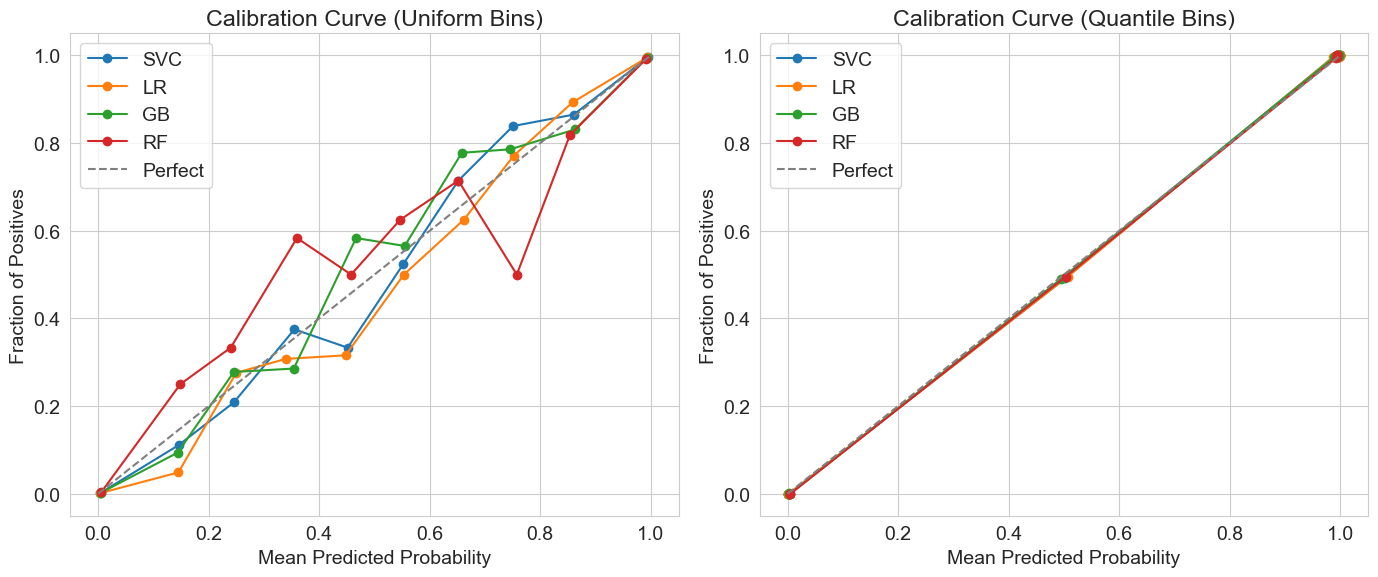

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, pred in [('SVC', sigmoid_svc_pred), ('LR', sigmoid_lr_pred), 
                   ('GB', sigmoid_gb_pred), ('RF', sigmoid_rf_pred)]:
    true_prob, pred_prob = calibration_curve(y_test, pred, n_bins=10, strategy='uniform')
    axes[0].plot(pred_prob, true_prob, marker='o', label=name)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect')
axes[0].set_title('Calibration Curve (Uniform Bins)')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].legend()

for name, pred in [('SVC', sigmoid_svc_pred), ('LR', sigmoid_lr_pred), 
                   ('GB', sigmoid_gb_pred), ('RF', sigmoid_rf_pred)]:
    true_prob, pred_prob = calibration_curve(y_test, pred, n_bins=10, strategy='quantile')
    axes[1].plot(pred_prob, true_prob, marker='o', label=name)
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect')
axes[1].set_title('Calibration Curve (Quantile Bins)')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives')
axes[1].legend()

plt.tight_layout()
plt.show()

# Вывод: Quantile bins обеспечивают примерно равное число семплов в каждом бине, что делает оценку более
# стабильной, особенно когда предсказания сконцентрированы в узком диапазоне


**Задание**: Посчитайте метрику для неоткалиброванного классификатора.

In [84]:
print("ECE для неоткалиброванных моделей:")
print('SVC binary-ECE = ', binary_ECE(y_test, (svc_pred - svc_pred.min()) / (svc_pred.max() - svc_pred.min())))
print('LR binary-ECE = ', binary_ECE(y_test, lr.predict_proba(X_test)[:, 1]))
print('GB binary-ECE = ', binary_ECE(y_test, gb.predict_proba(X_test)[:, 1]))
print('RF binary-ECE = ', binary_ECE(y_test, rf.predict_proba(X_test)[:, 1]))

print("\nBrier score для неоткалиброванных моделей:")
print('SVC brier = ', brier_score_loss(y_test, (svc_pred - svc_pred.min()) / (svc_pred.max() - svc_pred.min())))
print('LR brier = ', brier_score_loss(y_test, lr.predict_proba(X_test)[:, 1]))
print('GB brier = ', brier_score_loss(y_test, gb.predict_proba(X_test)[:, 1]))
print('RF brier = ', brier_score_loss(y_test, rf.predict_proba(X_test)[:, 1]))


ECE для неоткалиброванных моделей:
SVC binary-ECE =  0.28534636631236876
LR binary-ECE =  0.006611511041151015
GB binary-ECE =  0.005608642861334206
RF binary-ECE =  0.0025606234517145886

Brier score для неоткалиброванных моделей:
SVC brier =  0.10358435720414363
LR brier =  0.008708760194226426
GB brier =  0.008841058951713502
RF brier =  0.00812029049534167


**Вопрос**: Как можно адаптировать MCE/ECE для мультиклассовой задачи? Напишите формулы.
*Ответ*: использовать выигравший класс. Можно сделать бинарные есе для всех классов и потом усреднить по классам.

ОТВЕТ НА ВОПРОС
Для мультиклассовой задачи есть несколько подходов:

1. OvR-ECE: Вычисляется ECE для каждого класса отдельно, затем усредняется:
   $$ECE_{ovr} = \frac{1}{K} \sum_{k=1}^{K} ECE_k$$
   где $ECE_k$ вычисляется для бинарной задачи класс $k$ vs остальные.

2. Top-label ECE: Рассматривается только класс с максимальной предсказанной вероятностью:
   $$ECE_{top} = \mathbb{E}[|acc(conf) - conf|]$$
   где $conf = \max_k \hat{p}_k(x)$, а $acc(conf)$ — доля правильных предсказаний среди объектов с уверенностью $conf$.

3. Class-conditional ECE: Условное матожидание ошибки калибровки при условии предсказанного класса:
   $$ECE_{class} = \sum_{k=1}^{K} P(\hat{y}=k) \cdot \mathbb{E}[|P(y=k|\hat{p}_k) - \hat{p}_k| \mid \hat{y}=k]$$

4. Multinomial ECE: Обобщение на весь вектор вероятностей:
   $$ECE_{multi} = \mathbb{E}\left[\|\mathbf{p}(x) - \hat{\mathbf{p}}(x)\|_2\right]$$

В случае мультикласса, у нас возникает несколько сложностей: во-первых, в случае большого числа классов число бинов будет очень большим, при этом многие будут пустыми. Да и само определение реальной ECE пока не сделано. 

**Задание:** посчитайте ECE для модели, которая предсказывает пропорцию классов. Какие знаечения ECE и лосса у нее будут? Что изменится, если модель начнет предсказывать 0.9 для позитивных семплов и продолжит предсказывать пропорцию классов для негадивных?

In [85]:
class_ratio = y_train.mean()
constant_pred = np.full(len(y_test), class_ratio)

ece_constant = binary_ECE(y_test, constant_pred)
brier_constant = brier_score_loss(y_test, constant_pred)
logloss_constant = log_loss(y_test, np.column_stack([1 - constant_pred, constant_pred]))

print(f"Доля положительного класса: {class_ratio:.4f}")
print(f"ECE для модели с постоянной вероятностью: {ece_constant:.4f}")
print(f"Brier score: {brier_constant:.4f}")
print(f"Log-loss: {logloss_constant:.4f}")

smart_pred = np.where(y_test == 1, 0.9, class_ratio)
ece_smart = binary_ECE(y_test, smart_pred)
brier_smart = brier_score_loss(y_test, smart_pred)
logloss_smart = log_loss(y_test, np.column_stack([1 - smart_pred, smart_pred]))

print(f"\nECE для 'умной' модели (0.9 для positive, {class_ratio:.4f} для negative): {ece_smart:.4f}")
print(f"Brier score: {brier_smart:.4f}")
print(f"Log-loss: {logloss_smart:.4f}")

# Вывод: Модель с постоянной вероятностью имеет ECE = 0, но плохой Brier score и log-loss,
# так как не различает объекты. Умная модель имеет худшую калибровку, но лучшие predictive метрики.
# Это показывает, что калиброванность != точность предсказаний

Доля положительного класса: 0.5494
ECE для модели с постоянной вероятностью: 0.0009
Brier score: 0.2476
Log-loss: 0.6884

ECE для 'умной' модели (0.9 для positive, 0.5494 для negative): 0.3029
Brier score: 0.1418
Log-loss: 0.4177


Можно посчитать калиброванность и на уровне семплов.

**Brier score.** Тоже одна из популярных метрик, которая попросту измеряет разницу между предсказанными вероятностями и $ y_i $ (обратите внимание, что $ y_i $  - это либо 0, либо 1):
$$ \sum^N_{i=1}(y_i - q (x_i))^2,$$ 
для бинарного случая, и
$$ {1 \over N} \sum^N_{n=1}\sum^K_{j=1} (I(y_n=j) - q_{nj})^2,$$ 
для мультикласса.

**Вопрос**: Какое значение соответствует лучшей калибрации? Какие максимальные и минимальные значения он можеит принимать?

ОТВЕТ НА ВОПРОС
Для Brier score:
Лучшая калибрация: $BS = 0$ (идеальное совпадение предсказанных вероятностей с истинными метками).
Минимальное значение: $0$ (идеальная модель).
Максимальное значение: $1$ (модель всегда предсказывает противоположное: $p=1$ когда $y=0$, и $p=0$ когда $y=1$).
Baseline: $BS = p(1-p)$, где $p$ — доля положительного класса. Для сбалансированных данных это $0.25$.

Brier score можно разложить на три компоненты:
$$BS = \text{Uncertainty} - \text{Resolution} + \text{Reliability}$$
где Reliability — это мера калиброванности

Также можно использовать log-loss:
$$ {-1\over N} {\sum^N_{n=1}\sum^K_{j=1}I(y_n=j)log(q_{n,j})}$$

Для достаточно гладких классификатора и датасета brier score и log-loss будут адекватными средствами оценки, но если нет — возможно всякое.

In [86]:
print('Log-loss (ниже — лучше):')
print('Platt SVC =', log_loss(y_test, np.column_stack([1 - sigmoid_svc_pred, sigmoid_svc_pred])))
print('Platt LR =', log_loss(y_test, np.column_stack([1 - sigmoid_lr_pred, sigmoid_lr_pred])))
print('Platt GB =', log_loss(y_test, np.column_stack([1 - sigmoid_gb_pred, sigmoid_gb_pred])))
print('Platt RF =', log_loss(y_test, np.column_stack([1 - sigmoid_rf_pred, sigmoid_rf_pred])))
print('Isotonic SVC =', log_loss(y_test, np.column_stack([1 - isotonic_svc_pred, isotonic_svc_pred])))
print('Isotonic LR =', log_loss(y_test, np.column_stack([1 - isotonic_lr_pred, isotonic_lr_pred])))
print('Isotonic GB =', log_loss(y_test, np.column_stack([1 - isotonic_gb_pred, isotonic_gb_pred])))
print('Isotonic RF =', log_loss(y_test, np.column_stack([1 - isotonic_rf_pred, isotonic_rf_pred])))

Log-loss (ниже — лучше):
Platt SVC = 0.03127628553173257
Platt LR = 0.03332624553089856
Platt GB = 0.03330560491694385
Platt RF = 0.03889978089822564
Isotonic SVC = 0.030862017941731237
Isotonic LR = 0.03362505591061998
Isotonic GB = 0.03185813379041481
Isotonic RF = 0.03177237275486132


In [87]:
print("Platt:")
print('SVC brier score = ', brier_score_loss(y_test, sigmoid_svc_pred, pos_label=1))
print('Linear brier score = ', brier_score_loss(y_test, sigmoid_lr_pred, pos_label=1))
print('GB brier score = ', brier_score_loss(y_test, sigmoid_gb_pred, pos_label=1))
print('RF brier score = ', brier_score_loss(y_test, sigmoid_rf_pred, pos_label=1))

print("Isotonic:")
print('SVC brier score = ', brier_score_loss(y_test, isotonic_svc_pred, pos_label=1))
print('Linear brier score = ', brier_score_loss(y_test, isotonic_lr_pred, pos_label=1))
print('GB brier score = ', brier_score_loss(y_test, isotonic_gb_pred, pos_label=1))
print('RF brier score = ', brier_score_loss(y_test, isotonic_rf_pred, pos_label=1))

Platt:
SVC brier score =  0.008190798964867128
Linear brier score =  0.008657533566194723
GB brier score =  0.008324432515465508
RF brier score =  0.008414267921423881
Isotonic:
SVC brier score =  0.008210667088002655
Linear brier score =  0.008753390327467463
GB brier score =  0.008308572212625685
RF brier score =  0.0081537987804715


**Задание**: Посчитайте метрику для неоткалиброванного классификатора.

Итак, мы откалибровали наши классификаторы. Теперь мы можем оценить, как поменяются метрики после этого. Так, по идее точность, f1 не должны сильно поменяться, так как вблизи от границы разделения вероятности не должны сильно измениться. Так ли это?
Теперь **вопрос**: Изменится ли после калибрации ROC-AUC и как? Можете ли вы ответить на вопрос без измерений?

ROC-AUC не изменится после калибровки, если калибровка применяет монотонное преобразование к предсказаниям.

Причина: ROC-AUC зависит только от порядка предсказаний, а не от их абсолютных значений. И калибровка Платта ($\sigma(af(x)+b)$), и изотоническая регрессия — это монотонно возрастающие функции, которые сохраняют порядок объектов.

Однако, если калибровка выполняется через кросс-валидацию, то предсказания для разных объектов могут получаться от разных фолдовых моделей, что теоретически может немного изменить порядок. Но на практике это изменение обычно пренебрежимо мало.

**Вывод**: Калибровка улучшает вероятности, но не улучшает ранжирующую способность модели

**Задание**: Обучите дерево решений и случайный лес.

In [91]:

dt = DecisionTreeClassifier(max_depth=5, random_state=SEED).fit(X_train, y_train)
dt_pred = dt.predict_proba(X_test)[:, 1]
print('Decision Tree ROC-AUC:', roc_auc_score(y_test, dt_pred))

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED).fit(X_train, y_train)
rf_pred = rf.predict_proba(X_test)[:, 1]
print('Random Forest ROC-AUC:', roc_auc_score(y_test, rf_pred))


Decision Tree ROC-AUC: 0.9952492757472242
Random Forest ROC-AUC: 0.9991008275866279


**Задание**: Откалибройте изотоническим методом. Постройте калибровочные кривые для классификаторов, до и после калибровки.

DT (isotonic) ROC-AUC: 0.9985426416223262
DT (sigmoid) ROC-AUC: 0.998475138821475


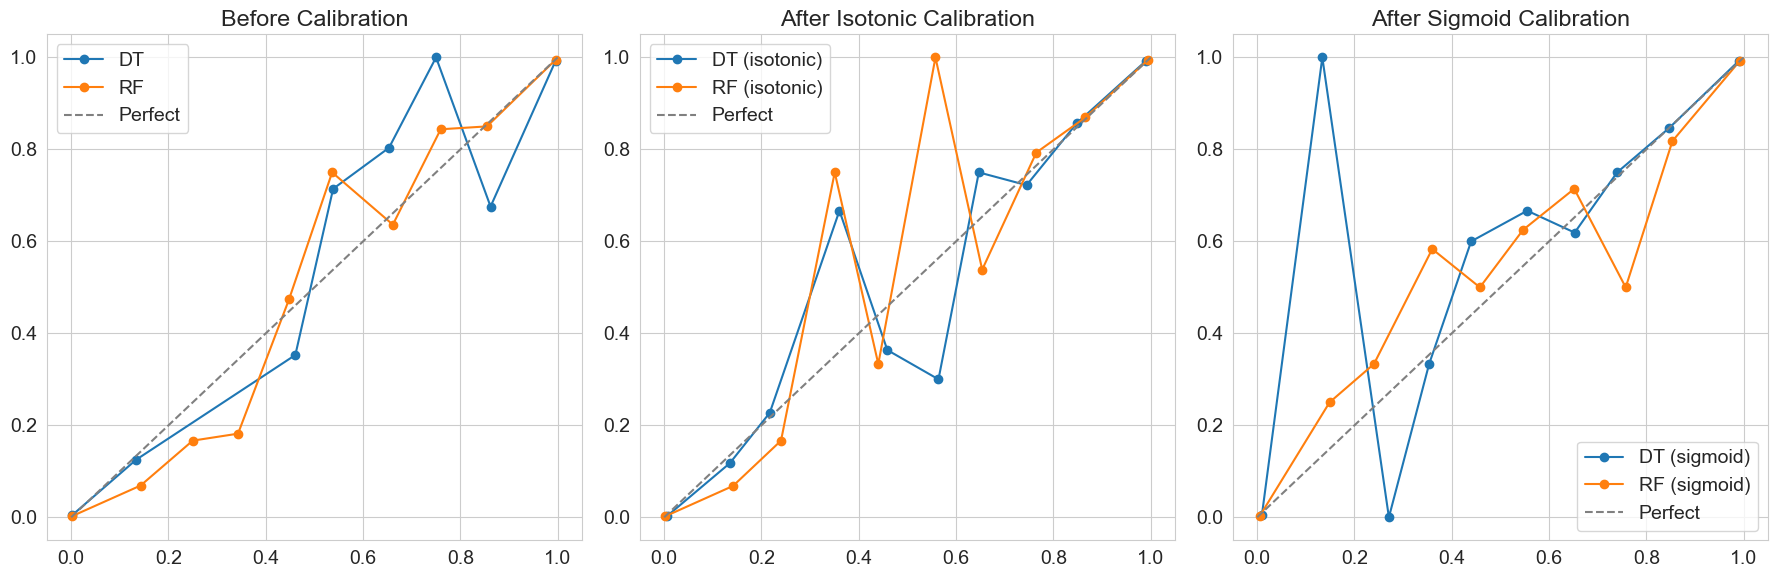

In [92]:
isotonic_dt = CalibratedClassifierCV(dt, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_dt_pred = isotonic_dt.predict_proba(X_test)[:, 1]
print('DT (isotonic) ROC-AUC:', roc_auc_score(y_test, isotonic_dt_pred))

sigmoid_dt = CalibratedClassifierCV(dt, cv=3, method='sigmoid').fit(X_train, y_train)
sigmoid_dt_pred = sigmoid_dt.predict_proba(X_test)[:, 1]
print('DT (sigmoid) ROC-AUC:', roc_auc_score(y_test, sigmoid_dt_pred))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for name, pred in [('DT', dt_pred), ('RF', rf_pred)]:
    true_prob, pred_prob = calibration_curve(y_test, pred, n_bins=10)
    axes[0].plot(pred_prob, true_prob, marker='o', label=name)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect')
axes[0].set_title('Before Calibration')
axes[0].legend()

for name, pred in [('DT (isotonic)', isotonic_dt_pred), ('RF (isotonic)', isotonic_rf_pred)]:
    true_prob, pred_prob = calibration_curve(y_test, pred, n_bins=10)
    axes[1].plot(pred_prob, true_prob, marker='o', label=name)
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect')
axes[1].set_title('After Isotonic Calibration')
axes[1].legend()

for name, pred in [('DT (sigmoid)', sigmoid_dt_pred), ('RF (sigmoid)', sigmoid_rf_pred)]:
    true_prob, pred_prob = calibration_curve(y_test, pred, n_bins=10)
    axes[2].plot(pred_prob, true_prob, marker='o', label=name)
axes[2].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect')
axes[2].set_title('After Sigmoid Calibration')
axes[2].legend()

plt.tight_layout()
plt.show()


ВОпрос: Какой вывод можно сделать из графиков?

ОТВЕТ НА ВОПРОС
1. Дерево решений обычно выдаёт вероятности, близкие к 0 или 1, что приводит к S-образной калибровочной кривой 
2. Изотоническая калибровка лучше справляется с деревьями, так как может исправить любую монотонную деформацию, но склонна к переобучению на малых выборках
3. Sigmoid калибровка хорошо работает для моделей, у которых распределение скоров близко к нормальному, но может не справиться с деревьями
4. Random Forest уже имеет неплохую калибровку благодаря усреднению, но всё ещё страдает от сжатия вероятностей к центру.

**Задание**: Какой из классификаторов в итоге лучше откалиброван (среди всех)? Покажите в сравнении. Какой вы выберете далее?

Рейтинг моделей по ECE (меньше — лучше):


,Model,ECE,Brier,ROC-AUC
9,SVC (Isotonic),0.002086,0.008211,0.999099
10,LR (Isotonic),0.002151,0.008753,0.998938
11,GB (Isotonic),0.002293,0.008309,0.998996
3,RF (raw),0.002561,0.008120,0.999101
8,RF (Platt),0.002627,0.008414,0.999083
12,RF (Isotonic),0.002655,0.008154,0.999128
5,SVC (Platt),0.002782,0.008191,0.999134
6,LR (Platt),0.003448,0.008658,0.998978
7,GB (Platt),0.003569,0.008324,0.999062
13,DT (Isotonic),0.003851,0.008796,0.998543


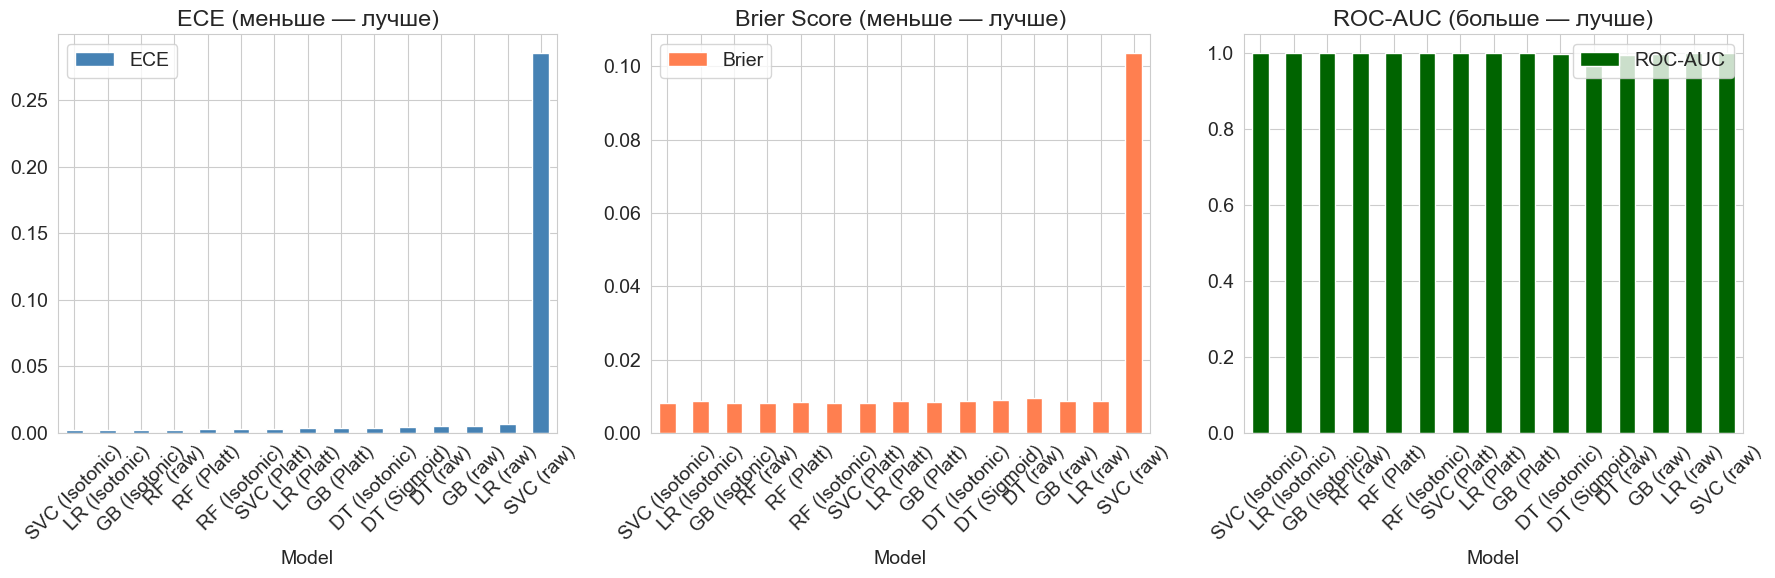

In [ ]:
results = []

models_preds = {
    'SVC (raw)': (svc_pred - svc_pred.min()) / (svc_pred.max() - svc_pred.min()),
    'LR (raw)': lr.predict_proba(X_test)[:, 1],
    'GB (raw)': gb.predict_proba(X_test)[:, 1],
    'RF (raw)': rf.predict_proba(X_test)[:, 1],
    'DT (raw)': dt_pred,
    'SVC (Platt)': sigmoid_svc_pred,
    'LR (Platt)': sigmoid_lr_pred,
    'GB (Platt)': sigmoid_gb_pred,
    'RF (Platt)': sigmoid_rf_pred,
    'SVC (Isotonic)': isotonic_svc_pred,
    'LR (Isotonic)': isotonic_lr_pred,
    'GB (Isotonic)': isotonic_gb_pred,
    'RF (Isotonic)': isotonic_rf_pred,
    'DT (Isotonic)': isotonic_dt_pred,
    'DT (Sigmoid)': sigmoid_dt_pred,
}

for name, pred in models_preds.items():
    ece = binary_ECE(y_test, pred)
    brier = brier_score_loss(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred)
    results.append({'Model': name, 'ECE': ece, 'Brier': brier, 'ROC-AUC': roc_auc})

results_df = pd.DataFrame(results).sort_values('ECE')
print("Рейтинг моделей по ECE (меньше — лучше):")
display(results_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
results_df.plot(x='Model', y='ECE', kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('ECE (меньше — лучше)')
axes[0].tick_params(axis='x', rotation=45)

results_df.plot(x='Model', y='Brier', kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Brier Score (меньше — лучше)')
axes[1].tick_params(axis='x', rotation=45)

results_df.plot(x='Model', y='ROC-AUC', kind='bar', ax=axes[2], color='darkgreen')
axes[2].set_title('ROC-AUC (больше — лучше)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Вывод: Лучшая калиброванная модель та, у которой наименьший ECE и Brier score.
# Выбираем модель с лучшим балансом между ROC-AUC и калибровкой.


Больше информации - в [отличном туториале](https://classifier-calibration.github.io/ecml-pkdd-2020-tutorial/) и [материалах Дьяконова](https://web.archive.org/web/20240315204907/https://alexanderdyakonov.wordpress.com/2020/03/27/%D0%BF%D1%80%D0%BE%D0%B1%D0%BB%D0%B5%D0%BC%D0%B0-%D0%BA%D0%B0%D0%BB%D0%B8%D0%B1%D1%80%D0%BE%D0%B2%D0%BA%D0%B8-%D1%83%D0%B2%D0%B5%D1%80%D0%B5%D0%BD%D0%BD%D0%BE%D1%81%D1%82%D0%B8/).